# Logistic regression

Logistic regression models a linear score and maps it to a value between zero and one. The output is often used as a probability estimate, but the model and the decision rule are separate parts of the system.


## Score, probability, and threshold

The model first computes

```text
z = Xw + b
p(y=1 | x) = sigmoid(z)
```

The sigmoid gives a smooth score in `[0, 1]`. A threshold then determines which examples are treated as positive. `0.5` is a convention; it is not implied by the optimization problem or by the class distribution.


validation ROC-AUC: 0.966
validation PR-AUC:  0.869
selected threshold: 0.23 (validation recall=0.868)
test precision:     0.698
test recall:        0.811


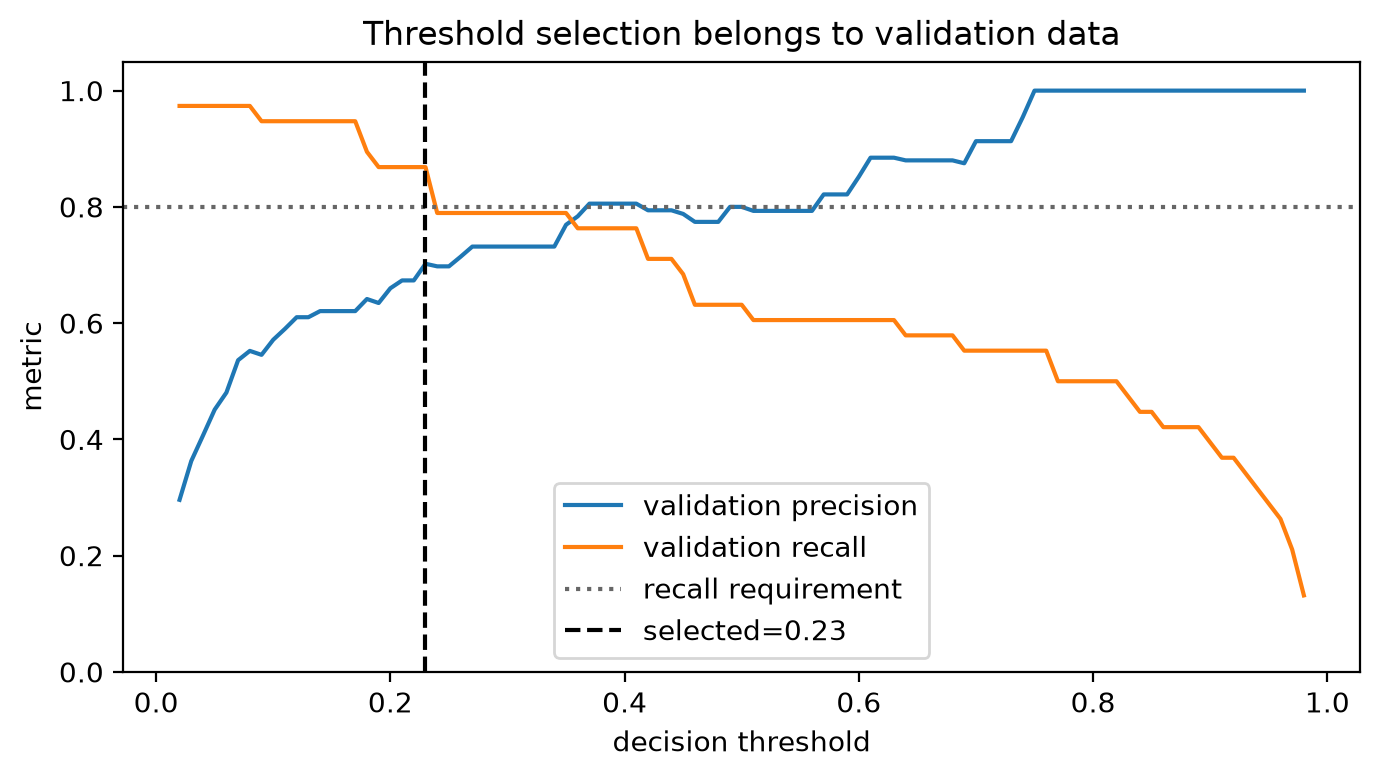

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

X, y = make_classification(n_samples=1_800, n_features=8, n_informative=4, weights=[0.9, 0.1], random_state=8)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, stratify=y, random_state=3)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=3)

model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1_000))
model.fit(X_train, y_train)
val_scores = model.predict_proba(X_val)[:, 1]
test_scores = model.predict_proba(X_test)[:, 1]
thresholds = np.linspace(0.02, 0.98, 97)
precision = np.array([precision_score(y_val, val_scores >= t, zero_division=0) for t in thresholds])
recall = np.array([recall_score(y_val, val_scores >= t) for t in thresholds])
eligible = np.flatnonzero(recall >= 0.80)
chosen_index = eligible[np.argmax(precision[eligible])]
chosen_threshold = thresholds[chosen_index]
test_prediction = test_scores >= chosen_threshold

print(f'validation ROC-AUC: {roc_auc_score(y_val, val_scores):.3f}')
print(f'validation PR-AUC:  {average_precision_score(y_val, val_scores):.3f}')
print(f'selected threshold: {chosen_threshold:.2f} (validation recall={recall[chosen_index]:.3f})')
print(f'test precision:     {precision_score(y_test, test_prediction, zero_division=0):.3f}')
print(f'test recall:        {recall_score(y_test, test_prediction):.3f}')

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(thresholds, precision, label='validation precision')
ax.plot(thresholds, recall, label='validation recall')
ax.axhline(0.80, color='0.4', linestyle=':', label='recall requirement')
ax.axvline(chosen_threshold, color='black', linestyle='--', label=f'selected={chosen_threshold:.2f}')
ax.set(xlabel='decision threshold', ylabel='metric', ylim=(0, 1.05), title='Threshold selection belongs to validation data')
ax.legend(loc='best')
fig.tight_layout()
plt.show()


## The imbalanced example

The dataset contains many more negative than positive examples. The model is fitted on the training partition. A threshold is selected using validation data by requiring recall of at least `0.80` and then choosing the eligible threshold with the highest precision. The test metrics are calculated after this choice is fixed.

ROC-AUC and PR-AUC describe ranking over many thresholds. Precision, recall, and false-positive rate describe the selected operating point.
